# Quantum Reachability Analysis - Quickstart

This notebook demonstrates the class-based API for quantum reachability analysis.

**Three criteria tested:**
- **Moment**: Tests positive definiteness of moment matrix (fast, no optimization)
- **Spectral**: Maximizes spectral overlap via L-BFGS-B
- **Krylov**: Maximizes Krylov subspace projection via L-BFGS-B (Lanczos iteration)

**Estimated runtime:** ~5-8 minutes

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from src.models import CanonicalQuditModel, QubitGridModel
from src.criteria import SpectralCriterion, KrylovCriterion, MomentCriterion, Verdict
from src.sampling import DensitySweep, SweepConfig

## Single Reachability Test (~10 seconds)

Test whether a random target state is reachable from |0⟩ using K=10 canonical operators.

In [2]:
model = CanonicalQuditModel(dim=8, seed=42)
submodel = model.sample_submodel(10)
phi = submodel.init_state()
psi = submodel.random_state()

print(f"Model: d={model.dim}, full basis L={model.K}, submodel K={submodel.K}")
print(f"rho = K/d^2 = {submodel.K / model.dim**2:.4f}")
print()

for Criterion in [MomentCriterion, SpectralCriterion, KrylovCriterion]:
    crit = Criterion(submodel, phi, psi, tau=0.99)
    result = crit.is_reachable(maxiter=100, restarts=3)
    print(f"  {Criterion.__name__:20s}: {result.verdict.value}, score={result.score:.4f}")

Model: d=8, full basis L=64, submodel K=10
rho = K/d^2 = 0.1562

  MomentCriterion     : inconclusive, score=0.0000
  SpectralCriterion   : unreachable, score=0.5821
  KrylovCriterion     : unreachable, score=0.5052


## Density Sweep: CanonicalQuditModel (~10-12 min)

Sweep over K values at d=8, 12, 16 to see phase transitions.

**Note on Moment criterion:** Unlike Spectral and Krylov (which maximize over lambda and are
guaranteed monotonic in K), the Moment criterion tests a *sufficient condition* for unreachability
(positive definiteness of Q + gamma*LL^T). Adding operators changes the structure of Q and L,
so P(unreachable) measured by Moment is **not guaranteed to be monotonically decreasing** in K.
Small fluctuations in the Moment curve are expected behavior, not noise.

In [3]:
config = SweepConfig(
    n_hamiltonians=20,
    n_targets=10,
    tau=0.99,
    maxiter=50,
    restarts=3,
)

canonical_results = {}
for d in [8, 12, 16]:
    print(f"\nCanonicalQuditModel d={d}")
    model = CanonicalQuditModel(dim=d, seed=42)
    sweep = DensitySweep(model, config)

    # Dense at low K to capture Moment, sparse at high K for Spectral/Krylov
    if d == 8:
        K_values = [2, 3, 4, 6, 8, 12, 16, 25]
    elif d == 12:
        K_values = [2, 4, 6, 8, 12, 18, 25, 35]
    else:  # d == 16
        K_values = [2, 4, 6, 10, 16, 20, 25, 35, 50]

    K_values = [k for k in K_values if k <= d * d - 1]
    canonical_results[d] = sweep.run(
        K_values, criteria=['moment', 'spectral', 'krylov'], early_stop_zeros=3)


CanonicalQuditModel d=8
  K=2/25, rho=0.0312... moment=0.89, spectral=1.00, krylov=1.00
  K=3/25, rho=0.0469... moment=0.69, spectral=1.00, krylov=1.00
  K=4/25, rho=0.0625... moment=0.27, spectral=1.00, krylov=1.00
  K=6/25, rho=0.0938... moment=0.17, spectral=1.00, krylov=0.90
  K=8/25, rho=0.1250... moment=0.26, spectral=0.80, krylov=0.52
  K=12/25, rho=0.1875... moment=0.10, spectral=0.32, krylov=0.18
  K=16/25, rho=0.2500... moment=0.00, spectral=0.08, krylov=0.01
  K=25/25, rho=0.3906... moment=0.00, spectral=0.00, krylov=0.00

CanonicalQuditModel d=12
  K=2/35, rho=0.0139... moment=0.94, spectral=1.00, krylov=1.00
  K=4/35, rho=0.0278... moment=0.66, spectral=1.00, krylov=1.00
  K=6/35, rho=0.0417... moment=0.26, spectral=1.00, krylov=0.93
  K=8/35, rho=0.0556... moment=0.27, spectral=1.00, krylov=0.80
  K=12/35, rho=0.0833... moment=0.10, spectral=0.93, krylov=0.33
  K=18/35, rho=0.1250... moment=0.05, spectral=0.46, krylov=0.06
  K=25/35, rho=0.1736... moment=0.00, spectral=0

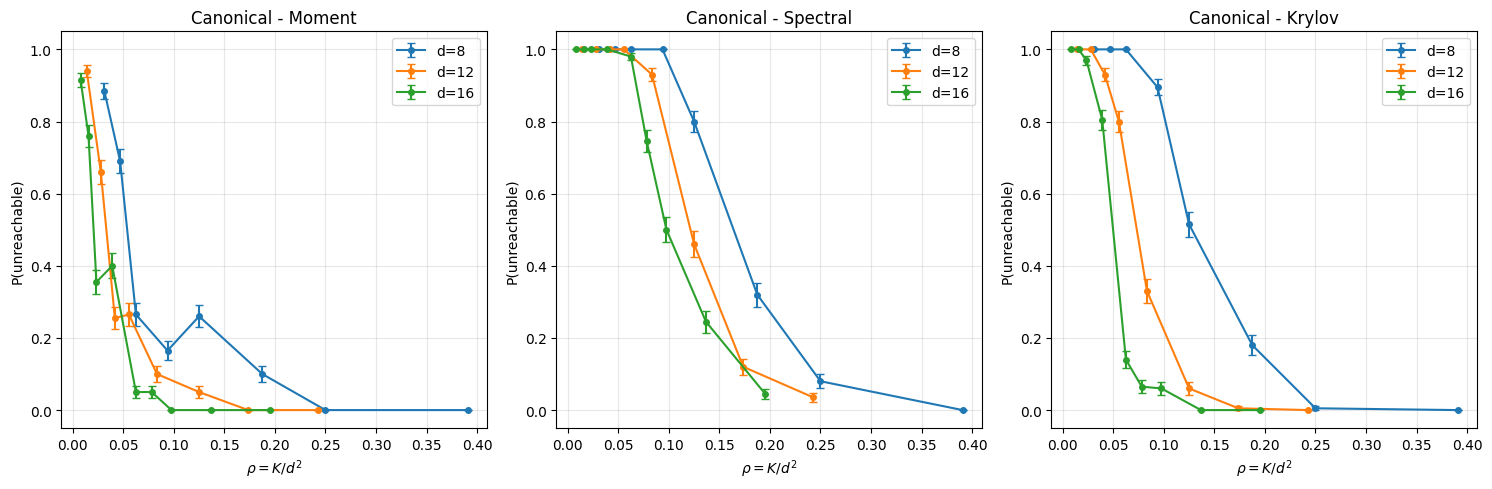

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, crit in zip(axes, ['moment', 'spectral', 'krylov']):
    for d, df in canonical_results.items():
        if len(df) == 0:
            continue
        ax.errorbar(df['rho'], df[f'{crit}_P'], yerr=df[f'{crit}_sem'],
                    fmt='o-', label=f'd={d}', capsize=3, markersize=4)
    ax.set_xlabel(r'$\rho = K/d^2$')
    ax.set_ylabel('P(unreachable)')
    ax.set_title(f'Canonical - {crit.capitalize()}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('../fig/quickstart_canonical.png', dpi=150, bbox_inches='tight')
plt.show()

## Density Sweep: QubitGridModel (~2-3 min)

Same sweep using Pauli operators on qubit lattices.

`sample_submodel(K)` selects K operators from the Pauli basis P_2(G) without replacement,
matching paper Sec. IV.B. Each H_k is a single 1-local or 2-local Pauli operator.

**Note on Krylov at small K:** At K=2-3, the L-BFGS-B optimizer has very few parameters
to optimize over, which can cause minor non-monotonicity in the Krylov curve due to
convergence issues (not physics). With more restarts or trials, these fluctuations smooth out.
By K ~ 5-10, generic Pauli operators span full space and Krylov drops to P=0.
See `krylov_qubitgrid_analysis.ipynb` for a detailed explanation.

In [5]:
qubit_results = {}
lattice_configs = {4: (1, 2), 8: (1, 3), 16: (2, 2)}

for d, (nx, ny) in lattice_configs.items():
    print(f"\nQubitGridModel d={d} ({nx}x{ny} lattice)")
    model = QubitGridModel(dim=d, nx=nx, ny=ny, seed=42)
    sweep = DensitySweep(model, config)

    # Dense at low K to capture Moment AND Krylov transitions
    L = model.K
    if d == 4:
        K_values = [2, 3, 4, 6, 8]
    elif d == 8:
        K_values = [2, 3, 4, 6, 8, 12, 16, 20]
    else:  # d == 16
        K_values = [2, 3, 4, 8, 12, 16, 24, 32]

    K_values = [k for k in K_values if k <= L]
    qubit_results[d] = sweep.run(
        K_values, criteria=['moment', 'spectral', 'krylov'], early_stop_zeros=3)


QubitGridModel d=4 (1x2 lattice)
  K=2/8, rho=0.1250... moment=0.40, spectral=0.97, krylov=0.84
  K=3/8, rho=0.1875... moment=0.00, spectral=0.80, krylov=0.29
  K=4/8, rho=0.2500... moment=0.00, spectral=0.34, krylov=0.20
  K=6/8, rho=0.3750... moment=0.00, spectral=0.00, krylov=0.00
  K=8/8, rho=0.5000... moment=0.00, spectral=0.00, krylov=0.00

QubitGridModel d=8 (1x3 lattice)
  K=2/20, rho=0.0312... moment=0.50, spectral=1.00, krylov=0.87
  K=3/20, rho=0.0469... moment=0.01, spectral=1.00, krylov=0.93
  K=4/20, rho=0.0625... moment=0.01, spectral=1.00, krylov=0.78
  K=6/20, rho=0.0938... moment=0.00, spectral=0.62, krylov=0.27
  K=8/20, rho=0.1250... moment=0.00, spectral=0.10, krylov=0.06
  K=12/20, rho=0.1875... moment=0.00, spectral=0.05, krylov=0.05
  K=16/20, rho=0.2500... moment=0.00, spectral=0.00, krylov=0.00
  K=20/20, rho=0.3125... moment=0.00, spectral=0.00, krylov=0.00

QubitGridModel d=16 (2x2 lattice)
  K=2/32, rho=0.0078... moment=0.39, spectral=1.00, krylov=0.86
  K

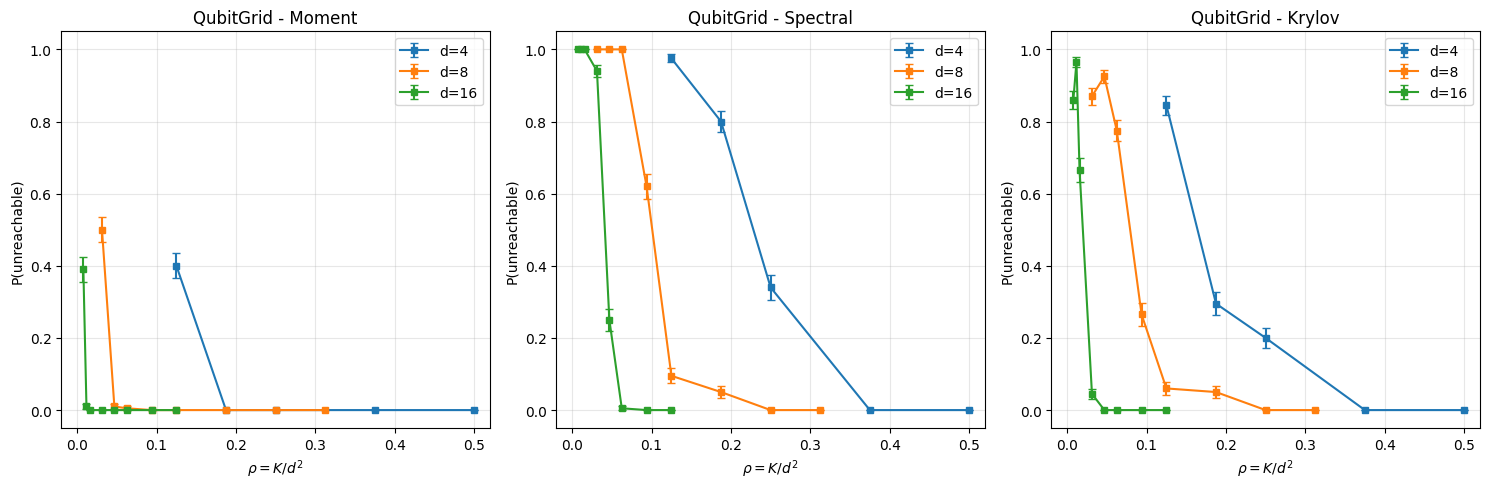

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, crit in zip(axes, ['moment', 'spectral', 'krylov']):
    for d, df in qubit_results.items():
        if len(df) == 0:
            continue
        ax.errorbar(df['rho'], df[f'{crit}_P'], yerr=df[f'{crit}_sem'],
                    fmt='s-', label=f'd={d}', capsize=3, markersize=4)
    ax.set_xlabel(r'$\rho = K/d^2$')
    ax.set_ylabel('P(unreachable)')
    ax.set_title(f'QubitGrid - {crit.capitalize()}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.02, 0.52)
plt.tight_layout()
plt.savefig('../fig/quickstart_qubitgrid.png', dpi=150, bbox_inches='tight')
plt.show()